# 3. Anomaly Detection
## Southeast Asian Daily Weather Patterns (2000–2024)

Detect statistically significant weather anomalies using three complementary methods:

| Method | Approach | Strength |
|---|---|---|
| **Z-Score** | Per station-month: flag days > 2.5σ from historical mean | Simple, interpretable |
| **IQR-Based** | Per station-month: flag days outside Q1–1.5·IQR / Q3+1.5·IQR | Robust to non-normal distributions |
| **Isolation Forest** | Multivariate ML on TMAX, TMIN, PRCP, TEMP_RANGE | Detects compound anomalies |

**Anomaly types detected:**
- Heatwaves (TMAX z-score > +2.5)
- Cold snaps (TMAX z-score < −2.5)
- Extreme rainfall (PRCP > 95th percentile per station-month)
- Compound anomalies (Isolation Forest, contamination=0.02)

## Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import Window
from pyspark.sql.functions import (
    col, avg, stddev, abs as spark_abs, count, when,
    percentile_approx, min as spark_min, max as spark_max,
    lit, year, month, to_date, concat_ws
)
import pyspark.sql.functions as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

spark = SparkSession.builder \
    .appName('GHCN-SEA-AnomalyDetection') \
    .config('spark.driver.memory', '8g') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.sql.shuffle.partitions', '100') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')

df = spark.read.parquet('../data/processed/sea_weather_2000_2024.parquet')
df.cache()
print(f"Loaded: {df.count():,} rows")

Loaded: 1,011,376 rows


---
## Method 1: Z-Score Anomaly Detection (PySpark Window Functions)

For each STATION_ID × MONTH combination, compute the 25-year historical mean and standard deviation. Flag any daily observation that deviates more than 2.5 standard deviations.

In [2]:
# ── Z-score: window partitioned by STATION_ID × MONTH ─────────────────────────
ZSCORE_THRESHOLD = 2.5

w_station_month = Window.partitionBy('STATION_ID', 'MONTH')

df_zscore = df.withColumn('TMAX_MEAN',  avg('TMAX').over(w_station_month)) \
              .withColumn('TMAX_STD',   stddev('TMAX').over(w_station_month)) \
              .withColumn('TMIN_MEAN',  avg('TMIN').over(w_station_month)) \
              .withColumn('TMIN_STD',   stddev('TMIN').over(w_station_month)) \
              .withColumn('TMAX_ZSCORE',
                  (col('TMAX') - col('TMAX_MEAN')) / col('TMAX_STD')) \
              .withColumn('TMIN_ZSCORE',
                  (col('TMIN') - col('TMIN_MEAN')) / col('TMIN_STD')) \
              .withColumn('ANOM_HEATWAVE',
                  col('TMAX_ZSCORE') > ZSCORE_THRESHOLD) \
              .withColumn('ANOM_COLD_SNAP',
                  col('TMAX_ZSCORE') < -ZSCORE_THRESHOLD) \
              .withColumn('ANOM_TMIN_HIGH',
                  col('TMIN_ZSCORE') > ZSCORE_THRESHOLD)

# Cache for reuse
df_zscore.cache()

# ── Batch counts: one Spark job instead of four ────────────────────────────
_counts = df_zscore.agg(
    count("*").alias("total"),
    count(when(col("ANOM_HEATWAVE"),   1)).alias("n_heatwave"),
    count(when(col("ANOM_COLD_SNAP"),  1)).alias("n_cold"),
    count(when(col("ANOM_TMIN_HIGH"),  1)).alias("n_warm_night"),
).collect()[0]
total, n_heatwave, n_cold, n_warm_night = (
    _counts.total, _counts.n_heatwave, _counts.n_cold, _counts.n_warm_night
)

print(f"{'Total observations:':<35} {total:>10,}")
print(f"{'Heatwave days (TMAX z > 2.5):':<35} {n_heatwave:>10,}  ({100*n_heatwave/total:.2f}%)")
print(f"{'Cold snap days (TMAX z < -2.5):':<35} {n_cold:>10,}  ({100*n_cold/total:.2f}%)")
print(f"{'Warm nights (TMIN z > 2.5):':<35} {n_warm_night:>10,}  ({100*n_warm_night/total:.2f}%)")

Total observations:                  1,011,376
Heatwave days (TMAX z > 2.5):            2,940  (0.29%)
Cold snap days (TMAX z < -2.5):         17,929  (1.77%)
Warm nights (TMIN z > 2.5):              3,256  (0.32%)


In [3]:
# ── Heatwave anomaly frequency by country and year ────────────────────────────
heatwave_yearly = df_zscore.filter(col('ANOM_HEATWAVE')) \
    .groupBy('COUNTRY', 'YEAR') \
    .agg(count('*').alias('heatwave_days')) \
    .orderBy('COUNTRY', 'YEAR')

# Normalise by observation count (per 1000 station-days) for fair comparison
obs_yearly = df_zscore.groupBy('COUNTRY', 'YEAR').agg(count('*').alias('total_obs'))

heatwave_rate = heatwave_yearly.join(obs_yearly, on=['COUNTRY', 'YEAR']) \
    .withColumn('heatwave_rate',
        (col('heatwave_days') / col('total_obs') * 1000)) \
    .toPandas()

cold_snap_yearly = df_zscore.filter(col('ANOM_COLD_SNAP')) \
    .groupBy('COUNTRY', 'YEAR') \
    .agg(count('*').alias('cold_days')) \
    .join(obs_yearly, on=['COUNTRY', 'YEAR']) \
    .withColumn('cold_rate', col('cold_days') / col('total_obs') * 1000) \
    .toPandas()

print(f"Heatwave data: {len(heatwave_rate)} country-year records")
print(heatwave_rate.groupby('COUNTRY')['heatwave_days'].sum().sort_values(ascending=False))

Heatwave data: 164 country-year records
COUNTRY
Indonesia      1745
Thailand        546
Philippines     256
Vietnam         182
Malaysia        111
Myanmar          46
Brunei           27
Laos             23
Singapore         4
Name: heatwave_days, dtype: int64


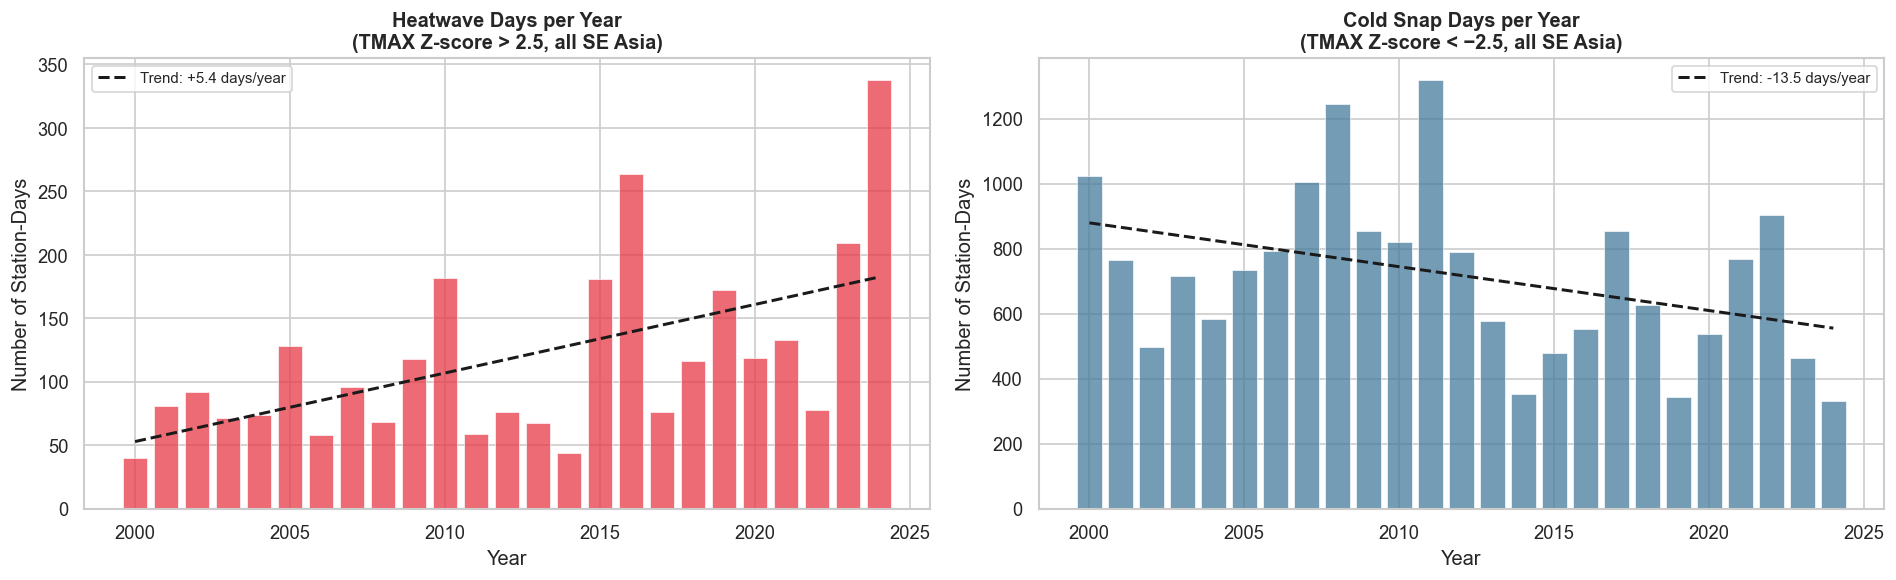

Anomaly frequency trend chart saved


In [4]:
# ── Anomaly frequency trend — bar chart per year (all countries) ───────────────
COUNTRIES_MAIN = ['Vietnam', 'Thailand', 'Philippines', 'Indonesia', 'Malaysia']
COUNTRY_COLORS = {
    'Vietnam': '#e63946', 'Thailand': '#2a9d8f', 'Philippines': '#e9c46a',
    'Indonesia': '#f4a261', 'Malaysia': '#457b9d', 'Myanmar': '#a8dadc',
    'Laos': '#6d6875', 'Brunei': '#b5838d', 'Singapore': '#e76f51', 'Cambodia': '#264653',
}

# Region-wide totals per year
hw_all = df_zscore.filter(col('ANOM_HEATWAVE')) \
    .groupBy('YEAR').agg(count('*').alias('heatwave_days')).toPandas().sort_values('YEAR')

cs_all = df_zscore.filter(col('ANOM_COLD_SNAP')) \
    .groupBy('YEAR').agg(count('*').alias('cold_days')).toPandas().sort_values('YEAR')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatwave trend
ax = axes[0]
bars = ax.bar(hw_all['YEAR'], hw_all['heatwave_days'],
              color='#e63946', alpha=0.75, edgecolor='white', linewidth=0.5)
# Trendline
from sklearn.linear_model import LinearRegression
X = hw_all['YEAR'].values.reshape(-1, 1)
lr = LinearRegression().fit(X, hw_all['heatwave_days'].values)
ax.plot(hw_all['YEAR'], lr.predict(X), 'k--', linewidth=1.8,
        label=f'Trend: {lr.coef_[0]:+.1f} days/year')
ax.set_title('Heatwave Days per Year\n(TMAX Z-score > 2.5, all SE Asia)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Station-Days')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

# Cold snap trend
ax = axes[1]
ax.bar(cs_all['YEAR'], cs_all['cold_days'],
       color='#457b9d', alpha=0.75, edgecolor='white', linewidth=0.5)
X2 = cs_all['YEAR'].values.reshape(-1, 1)
lr2 = LinearRegression().fit(X2, cs_all['cold_days'].values)
ax.plot(cs_all['YEAR'], lr2.predict(X2), 'k--', linewidth=1.8,
        label=f'Trend: {lr2.coef_[0]:+.1f} days/year')
ax.set_title('Cold Snap Days per Year\n(TMAX Z-score < −2.5, all SE Asia)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Station-Days')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anom_01_zscore_frequency_trend.png', bbox_inches='tight')
plt.show()
print("Anomaly frequency trend chart saved")

---
## Method 2: IQR-Based Anomaly Detection

Compute Q1, Q3, and IQR per STATION_ID × MONTH using PySpark window approximations. Flag observations outside Q1 − 1.5·IQR or above Q3 + 1.5·IQR. Also flag extreme precipitation (PRCP > 95th percentile per station-month).

In [ ]:
# IQR: compute per station-month percentiles then join back 

station_month_stats = df.groupBy('STATION_ID', 'MONTH').agg(
    percentile_approx('TMAX', 0.25).alias('TMAX_Q1'),
    percentile_approx('TMAX', 0.75).alias('TMAX_Q3'),
    percentile_approx('PRCP', 0.95).alias('PRCP_P95'),
)

df_iqr = df.join(station_month_stats, on=['STATION_ID', 'MONTH'], how='left') \
    .withColumn('TMAX_IQR', col('TMAX_Q3') - col('TMAX_Q1')) \
    .withColumn('TMAX_IQR_LOW',  col('TMAX_Q1') - 1.5 * col('TMAX_IQR')) \
    .withColumn('TMAX_IQR_HIGH', col('TMAX_Q3') + 1.5 * col('TMAX_IQR')) \
    .withColumn('ANOM_IQR_HOT',  col('TMAX') > col('TMAX_IQR_HIGH')) \
    .withColumn('ANOM_IQR_COLD', col('TMAX') < col('TMAX_IQR_LOW')) \
    .withColumn('ANOM_EXTREME_RAIN',
        (col('PRCP').isNotNull()) & (col('PRCP') > col('PRCP_P95')))

df_iqr.cache()

# ── Batch counts: one Spark job instead of four ────────────────────────────
_iqr = df_iqr.agg(
    count(when(col("ANOM_IQR_HOT"),        1)).alias("n_iqr_hot"),
    count(when(col("ANOM_IQR_COLD"),       1)).alias("n_iqr_cold"),
    count(when(col("ANOM_EXTREME_RAIN"),   1)).alias("n_extr_rain"),
    count(when(col("PRCP").isNotNull(),    1)).alias("total_prcp"),
).collect()[0]
n_iqr_hot, n_iqr_cold, n_extr_rain, total_prcp = (
    _iqr.n_iqr_hot, _iqr.n_iqr_cold, _iqr.n_extr_rain, _iqr.total_prcp
)

print(f"{'IQR hot outliers (TMAX > Q3+1.5·IQR):':<45} {n_iqr_hot:>8,}")
print(f"{'IQR cold outliers (TMAX < Q1-1.5·IQR):':<45} {n_iqr_cold:>8,}")
print(f"{'Extreme rain (PRCP > 95th pct):':<45} {n_extr_rain:>8,}  ({100*n_extr_rain/total_prcp:.1f}% of prcp obs)")

IQR hot outliers (TMAX > Q3+1.5·IQR):            3,684
IQR cold outliers (TMAX < Q1-1.5·IQR):          22,562
Extreme rain (PRCP > 95th pct):                 15,928  (4.6% of prcp obs)


C:\Users\vubao\AppData\Local\Temp\ipykernel_13696\3698760702.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(er_pivot.index, rotation=45, ha='right', fontsize=7)


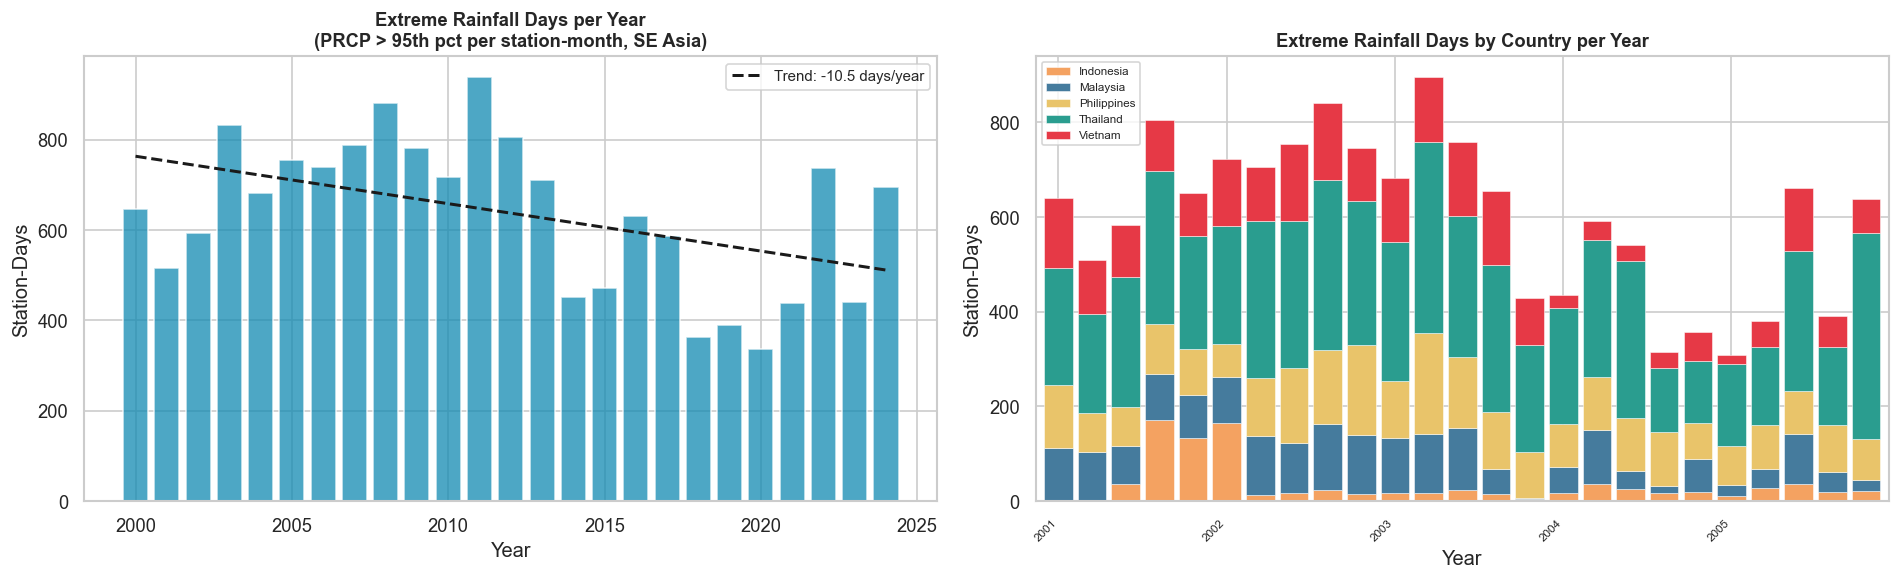

Extreme rainfall trend saved


In [ ]:
# Extreme rainfall trend by year 
extreme_rain_yearly = df_iqr.filter(col('ANOM_EXTREME_RAIN')) \
    .groupBy('COUNTRY', 'YEAR').agg(count('*').alias('extreme_rain_days')) \
    .toPandas()

rain_all = extreme_rain_yearly.groupby('YEAR')['extreme_rain_days'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Region-wide extreme rain bar chart
ax = axes[0]
ax.bar(rain_all['YEAR'], rain_all['extreme_rain_days'],
       color='#118ab2', alpha=0.75, edgecolor='white')
X_r = rain_all['YEAR'].values.reshape(-1, 1)
lr_r = LinearRegression().fit(X_r, rain_all['extreme_rain_days'].values)
ax.plot(rain_all['YEAR'], lr_r.predict(X_r), 'k--', linewidth=1.8,
        label=f'Trend: {lr_r.coef_[0]:+.1f} days/year')
ax.set_title('Extreme Rainfall Days per Year\n(PRCP > 95th pct per station-month, SE Asia)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Station-Days')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

# Per-country stacked bar
ax = axes[1]
er_pivot = extreme_rain_yearly[extreme_rain_yearly['COUNTRY'].isin(COUNTRIES_MAIN)] \
    .pivot_table(index='YEAR', columns='COUNTRY', values='extreme_rain_days', fill_value=0)
er_pivot.plot(kind='bar', stacked=True, ax=ax,
              color=[COUNTRY_COLORS[c] for c in er_pivot.columns],
              edgecolor='white', linewidth=0.3, width=0.85)
ax.set_title('Extreme Rainfall Days by Country per Year', fontsize=11, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Station-Days')
ax.legend(fontsize=7, loc='upper left')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.set_xticklabels(er_pivot.index, rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anom_02_extreme_rain_trend.png', bbox_inches='tight')
plt.show()
print("Extreme rainfall trend saved")

---
## Method 3: Isolation Forest (Multivariate ML)

Train an Isolation Forest on TMAX, TMIN, PRCP, TEMP_RANGE to detect compound anomalies — days that are simultaneously unusual across multiple variables (e.g., unusually hot AND unusually dry). Uses `contamination=0.02` (flags ~2% of data as anomalous).

In [ ]:
# Isolation Forest: pull data to Pandas, train per-country 

FEATURES = ['TMAX', 'TMIN', 'PRCP', 'TEMP_RANGE']

iso_input = df.select(
    'STATION_ID', 'DATE', 'YEAR', 'MONTH', 'COUNTRY',
    'TMAX', 'TMIN', 'PRCP', 'TEMP_RANGE'
).dropna(subset=['TMAX', 'TMIN', 'TEMP_RANGE']) \
 .fillna({'PRCP': 0.0}) \
 .toPandas()

print(f"Isolation Forest input: {len(iso_input):,} rows")

# Train one global model (all countries, standardised features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(iso_input[FEATURES])

iso_forest = IsolationForest(
    contamination=0.02,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_scaled)

iso_input['IF_SCORE']  = iso_forest.score_samples(X_scaled)   # lower = more anomalous
iso_input['IF_ANOMALY'] = iso_forest.predict(X_scaled) == -1  # True = anomaly

n_if = iso_input['IF_ANOMALY'].sum()
print(f"Isolation Forest anomalies flagged: {n_if:,}  ({100*n_if/len(iso_input):.1f}%)")

Isolation Forest input: 1,011,376 rows
Isolation Forest anomalies flagged: 20,228  (2.0%)


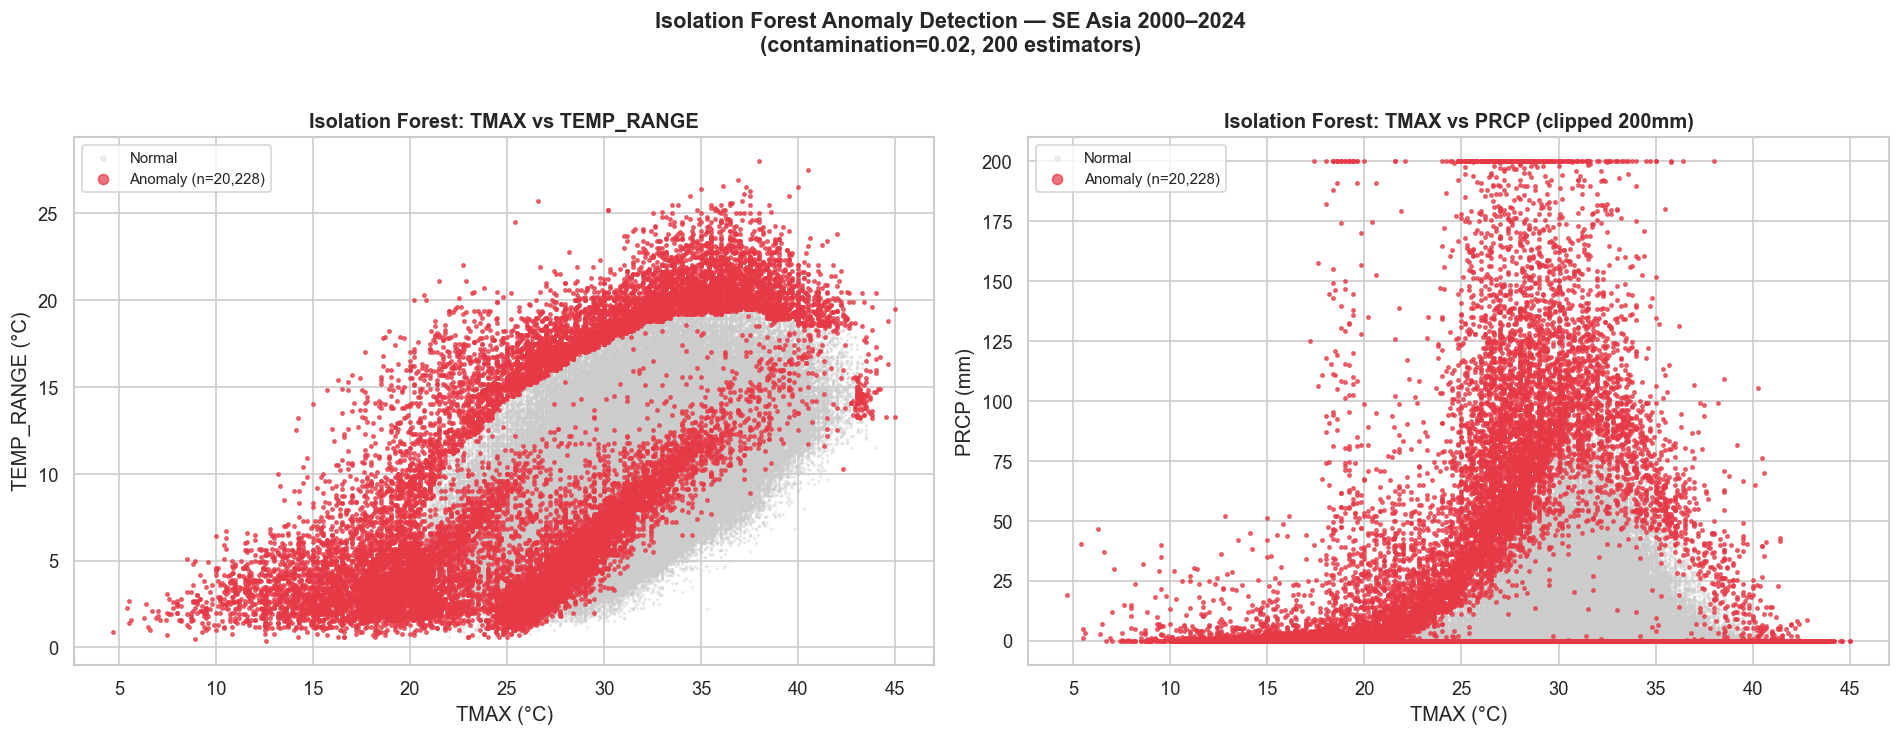

Isolation Forest scatter saved


In [ ]:
# Isolation Forest: scatter plot TMAX vs PRCP coloured by anomaly score 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: TMAX vs TEMP_RANGE
ax = axes[0]
normal = iso_input[~iso_input['IF_ANOMALY']]
anomaly = iso_input[iso_input['IF_ANOMALY']]

ax.scatter(normal['TMAX'], normal['TEMP_RANGE'],
           c='#cccccc', s=1, alpha=0.3, label='Normal', zorder=1)
ax.scatter(anomaly['TMAX'], anomaly['TEMP_RANGE'],
           c='#e63946', s=4, alpha=0.7, label=f'Anomaly (n={len(anomaly):,})', zorder=3)
ax.set_title('Isolation Forest: TMAX vs TEMP_RANGE', fontsize=12, fontweight='bold')
ax.set_xlabel('TMAX (°C)')
ax.set_ylabel('TEMP_RANGE (°C)')
ax.legend(fontsize=9, markerscale=3)

# Right: TMAX vs PRCP
ax = axes[1]
ax.scatter(normal['TMAX'], normal['PRCP'].clip(upper=200),
           c='#cccccc', s=1, alpha=0.3, label='Normal', zorder=1)
ax.scatter(anomaly['TMAX'], anomaly['PRCP'].clip(upper=200),
           c='#e63946', s=4, alpha=0.7, label=f'Anomaly (n={len(anomaly):,})', zorder=3)
ax.set_title('Isolation Forest: TMAX vs PRCP (clipped 200mm)', fontsize=12, fontweight='bold')
ax.set_xlabel('TMAX (°C)')
ax.set_ylabel('PRCP (mm)')
ax.legend(fontsize=9, markerscale=3)

plt.suptitle('Isolation Forest Anomaly Detection — SE Asia 2000–2024\n'
             '(contamination=0.02, 200 estimators)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anom_03_isolation_forest_scatter.png', bbox_inches='tight')
plt.show()
print("Isolation Forest scatter saved")

---
## Anomaly Catalogue & Method Comparison

Build a unified catalogue of all flagged events, compare method agreement, and produce the top-events table for the report.

In [ ]:
# Build unified anomaly catalogue
heatwave_catalogue = df_zscore.filter(col('ANOM_HEATWAVE')) \
    .select('DATE', 'STATION_ID', 'NAME', 'COUNTRY', 'YEAR', 'MONTH',
            'TMAX', 'TMAX_MEAN', 'TMAX_STD', 'TMAX_ZSCORE') \
    .withColumn('EVENT_TYPE', lit('Heatwave')) \
    .toPandas()

cold_catalogue = df_zscore.filter(col('ANOM_COLD_SNAP')) \
    .select('DATE', 'STATION_ID', 'NAME', 'COUNTRY', 'YEAR', 'MONTH',
            'TMAX', 'TMAX_MEAN', 'TMAX_STD', 'TMAX_ZSCORE') \
    .withColumn('EVENT_TYPE', lit('Cold Snap')) \
    .toPandas()

rain_catalogue = df_iqr.filter(col('ANOM_EXTREME_RAIN')) \
    .select('DATE', 'STATION_ID', 'NAME', 'COUNTRY', 'YEAR', 'MONTH',
            'PRCP', 'PRCP_P95') \
    .withColumn('EVENT_TYPE', lit('Extreme Rain')) \
    .toPandas()

print(f"Heatwave events:     {len(heatwave_catalogue):,}")
print(f"Cold snap events:    {len(cold_catalogue):,}")
print(f"Extreme rain events: {len(rain_catalogue):,}")
print(f"Total catalogued:    {len(heatwave_catalogue) + len(cold_catalogue) + len(rain_catalogue):,}")

Heatwave events:     2,940
Cold snap events:    17,929
Extreme rain events: 15,928
Total catalogued:    36,797


In [ ]:
# Top 20 most extreme heatwave events  
top_heatwaves = heatwave_catalogue.nlargest(20, 'TMAX_ZSCORE') \
    [['DATE', 'COUNTRY', 'NAME', 'TMAX', 'TMAX_MEAN', 'TMAX_ZSCORE', 'MONTH', 'YEAR']] \
    .reset_index(drop=True)

top_heatwaves.columns = ['Date', 'Country', 'Station', 'TMAX (°C)', 'Normal (°C)', 'Z-score', 'Month', 'Year']
top_heatwaves['TMAX (°C)'] = top_heatwaves['TMAX (°C)'].round(1)
top_heatwaves['Normal (°C)'] = top_heatwaves['Normal (°C)'].round(1)
top_heatwaves['Z-score'] = top_heatwaves['Z-score'].round(2)
print("TOP 20 MOST EXTREME HEATWAVE DAYS (by Z-score):")
print(top_heatwaves.to_string(index=False))

# Top 10 extreme rainfall events
top_rain = rain_catalogue.nlargest(10, 'PRCP') \
    [['DATE', 'COUNTRY', 'NAME', 'PRCP', 'PRCP_P95', 'YEAR']] \
    .reset_index(drop=True)
top_rain.columns = ['Date', 'Country', 'Station', 'PRCP (mm)', '95th pct (mm)', 'Year']
top_rain['PRCP (mm)'] = top_rain['PRCP (mm)'].round(1)
top_rain['95th pct (mm)'] = top_rain['95th pct (mm)'].round(1)
print("\nTOP 10 MOST EXTREME RAINFALL DAYS:")
print(top_rain.to_string(index=False))

TOP 20 MOST EXTREME HEATWAVE DAYS (by Z-score):
      Date     Country            Station  TMAX (°C)  Normal (°C)  Z-score  Month  Year
2002-11-24    Thailand           KO SAMUI       39.5         30.0     7.15     11  2002
2024-12-07    Thailand           SONGKHLA       37.9         29.9     5.89     12  2024
2016-01-19    Thailand            HUA HIN       38.5         29.8     5.89      1  2016
2019-03-22     Vietnam             CA MAU       39.0         32.4     5.85      3  2019
2005-05-30   Indonesia          SEPINGGAN       38.6         31.4     5.83      5  2005
2021-02-27    Thailand           KO SAMUI       35.1         29.5     5.79      2  2021
2019-03-23   Indonesia  MEULABOH/CUT NYAK       37.6         31.5     5.71      3  2019
2021-02-26    Thailand           KO SAMUI       35.0         29.5     5.69      2  2021
2011-12-17   Indonesia       SABU/TARDAMU       39.3         32.6     5.65     12  2011
2000-11-04   Indonesia          ENAROTALI       32.4         25.3     5.

C:\Users\vubao\AppData\Local\Temp\ipykernel_13696\3505664523.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison[_col] = comparison[_col].fillna(False).astype(bool)
C:\Users\vubao\AppData\Local\Temp\ipykernel_13696\3505664523.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison[_col] = comparison[_col].fillna(False).astype(bool)


METHOD AGREEMENT — Hot temperature anomalies:
  Both Z-score AND IQR flag:  2,468
  Z-score only:               472
  IQR only:                   1,216
  Agreement rate: 59.4%


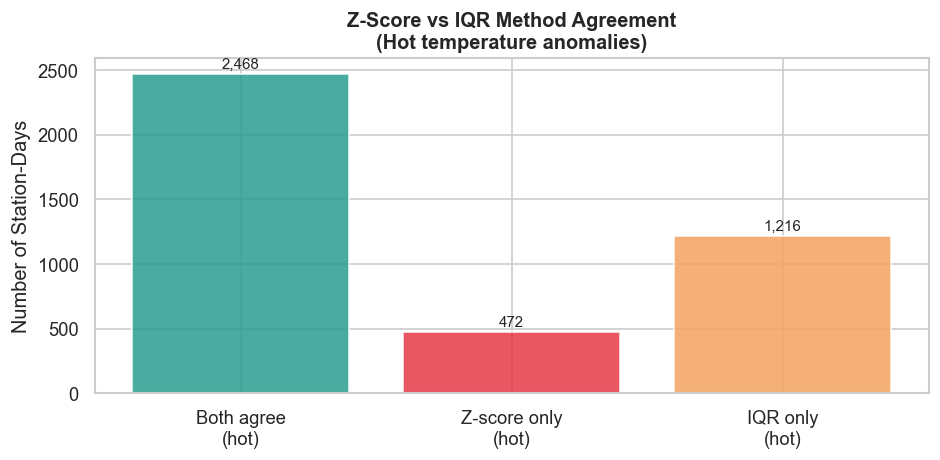

Method comparison chart saved


In [ ]:
# Method comparison: agreement between Z-score and IQR 
# Join Z-score and IQR flags on same base columns
comparison = df_zscore.select(
    'STATION_ID', 'DATE', 'COUNTRY', 'TMAX', 'ANOM_HEATWAVE', 'ANOM_COLD_SNAP'
).join(
    df_iqr.select('STATION_ID', 'DATE', 'ANOM_IQR_HOT', 'ANOM_IQR_COLD', 'ANOM_EXTREME_RAIN'),
    on=['STATION_ID', 'DATE']
).toPandas()

# Cast nullable booleans from PySpark join to proper bool (None -> False)
for _col in ["ANOM_HEATWAVE", "ANOM_COLD_SNAP", "ANOM_IQR_HOT", "ANOM_IQR_COLD", "ANOM_EXTREME_RAIN"]:
    comparison[_col] = comparison[_col].fillna(False).astype(bool)

# Agreement matrix
both_hot   = ((comparison['ANOM_HEATWAVE']) & (comparison['ANOM_IQR_HOT'])).sum()
zscore_only = ((comparison['ANOM_HEATWAVE']) & (~comparison['ANOM_IQR_HOT'])).sum()
iqr_only   = ((~comparison['ANOM_HEATWAVE']) & (comparison['ANOM_IQR_HOT'])).sum()

print("METHOD AGREEMENT — Hot temperature anomalies:")
print(f"  Both Z-score AND IQR flag:  {both_hot:,}")
print(f"  Z-score only:               {zscore_only:,}")
print(f"  IQR only:                   {iqr_only:,}")
print(f"  Agreement rate: {100*both_hot/(both_hot+zscore_only+iqr_only):.1f}%")

# Visualise as Venn-style bar
fig, ax = plt.subplots(figsize=(8, 4))
categories = ['Both agree\n(hot)', 'Z-score only\n(hot)', 'IQR only\n(hot)']
values = [both_hot, zscore_only, iqr_only]
colors = ['#2a9d8f', '#e63946', '#f4a261']
ax.bar(categories, values, color=colors, edgecolor='white', alpha=0.85)
ax.set_title('Z-Score vs IQR Method Agreement\n(Hot temperature anomalies)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Station-Days')
for i, v in enumerate(values):
    ax.text(i, v + max(values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anom_04_method_comparison.png', bbox_inches='tight')
plt.show()
print("Method comparison chart saved")

---
## Case Studies: Notable Anomaly Events

Identify 2–3 specific documented extreme weather events to contextualise the detected anomalies.

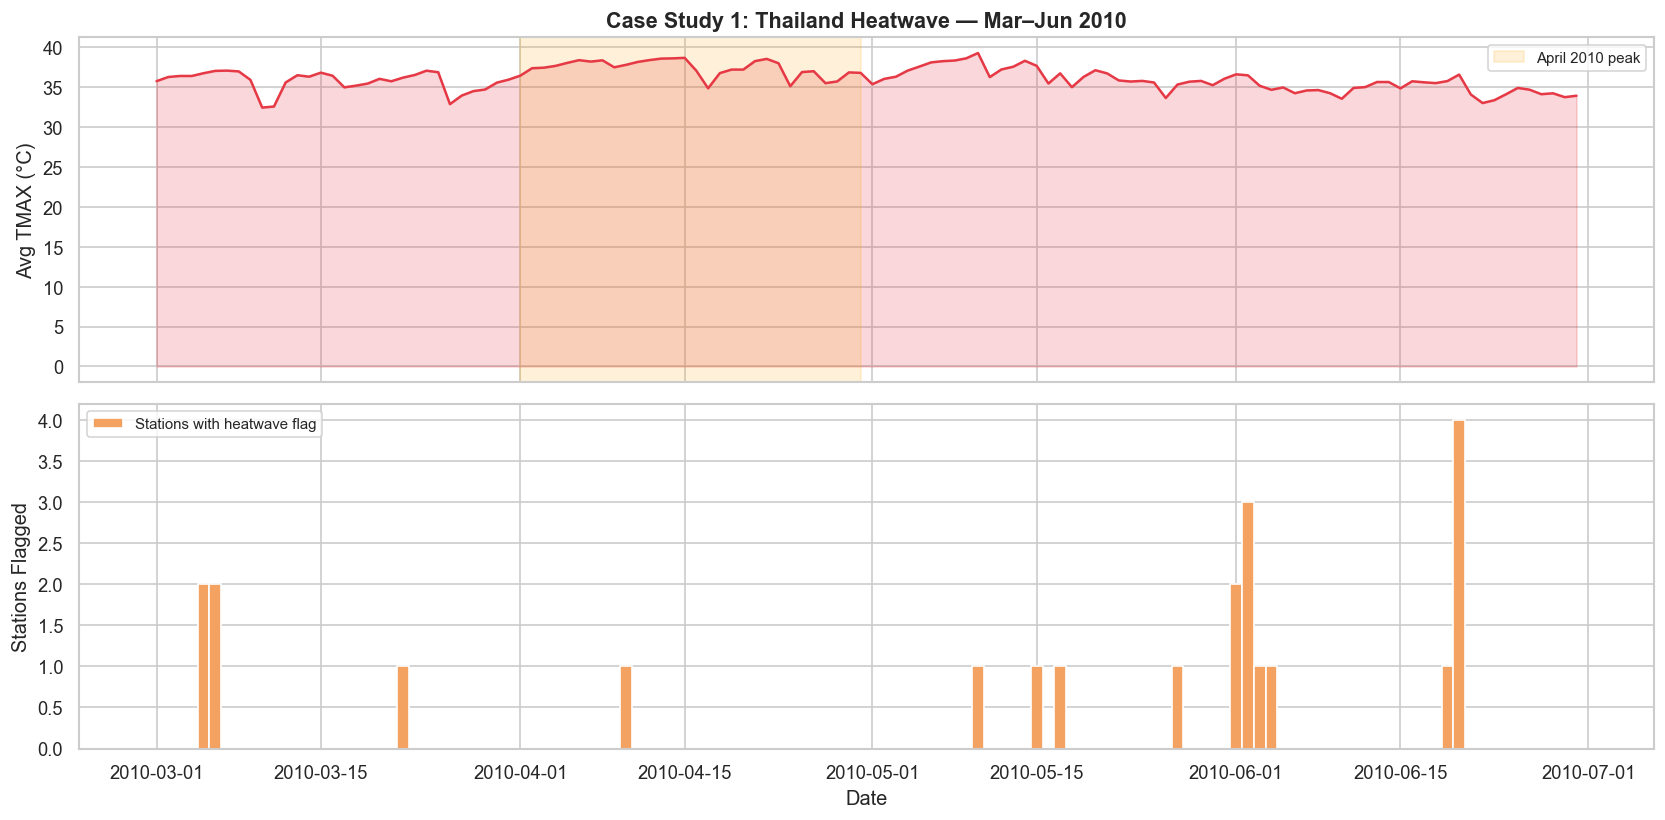

  Peak heatwave stations flagged: 4
  Highest avg TMAX in period: 39.3 °C


In [ ]:
# Case Study 1: Thailand 2010 heatwave 
# April 2010 is documented as one of Thailand's hottest months on record
cs1_period = ('2010-03-01', '2010-06-30')

cs1 = df_zscore.filter(
    (col('COUNTRY') == 'Thailand') &
    (col('DATE') >= cs1_period[0]) &
    (col('DATE') <= cs1_period[1])
).select('DATE', 'STATION_ID', 'NAME', 'TMAX', 'TMAX_MEAN', 'TMAX_ZSCORE', 'ANOM_HEATWAVE') \
 .toPandas()
cs1['DATE'] = pd.to_datetime(cs1['DATE'])

cs1_daily = cs1.groupby('DATE').agg(
    avg_TMAX=('TMAX', 'mean'),
    avg_ZSCORE=('TMAX_ZSCORE', 'mean'),
    heatwave_stations=('ANOM_HEATWAVE', 'sum'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(cs1_daily['DATE'], cs1_daily['avg_TMAX'], color='#e63946', linewidth=1.5)
ax1.fill_between(cs1_daily['DATE'], cs1_daily['avg_TMAX'],
                 alpha=0.2, color='#e63946')
ax1.set_ylabel('Avg TMAX (°C)')
ax1.set_title('Case Study 1: Thailand Heatwave — Mar–Jun 2010', fontsize=13, fontweight='bold')
ax1.axvspan(pd.Timestamp('2010-04-01'), pd.Timestamp('2010-04-30'),
            alpha=0.15, color='orange', label='April 2010 peak')
ax1.legend(fontsize=9)

ax2.bar(cs1_daily['DATE'], cs1_daily['heatwave_stations'],
        color='#f4a261', width=1.0, label='Stations with heatwave flag')
ax2.set_ylabel('Stations Flagged')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anom_05_case_study_thailand_2010.png', bbox_inches='tight')
plt.show()
print(f"  Peak heatwave stations flagged: {cs1_daily['heatwave_stations'].max():.0f}")
print(f"  Highest avg TMAX in period: {cs1_daily['avg_TMAX'].max():.1f} °C")

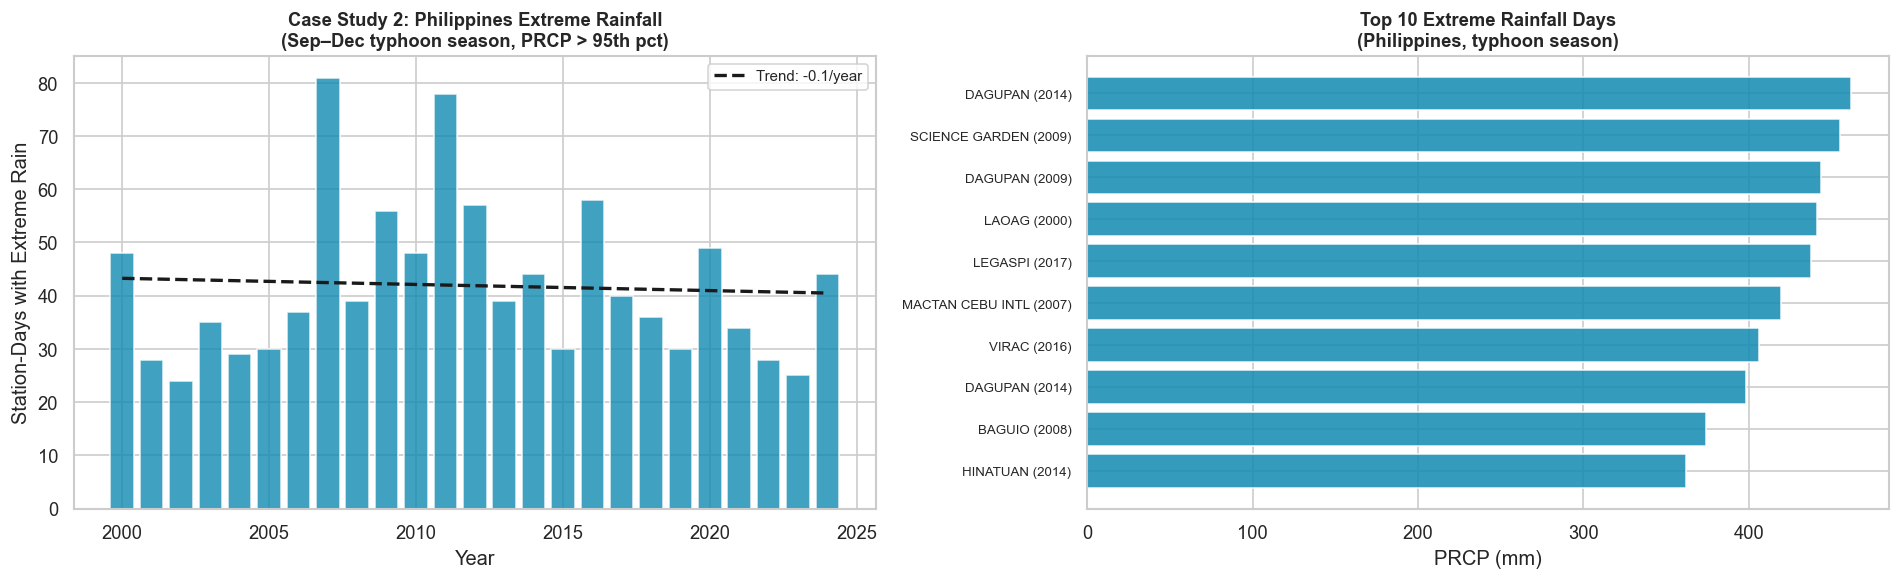

Philippines case study saved


In [ ]:
# Case Study 2: Philippines extreme rainfall — typhoon season
# Philippines is exposed to 20+ typhoons/year; Oct–Dec are peak months
cs2 = df_iqr.filter(
    (col('COUNTRY') == 'Philippines') &
    (col('MONTH').isin([9, 10, 11, 12]))
).select('DATE', 'YEAR', 'MONTH', 'STATION_ID', 'NAME', 'PRCP', 'PRCP_P95', 'ANOM_EXTREME_RAIN') \
 .toPandas()

# Yearly extreme rain count in typhoon season
cs2_yearly = cs2.groupby('YEAR')['ANOM_EXTREME_RAIN'].sum().reset_index()
cs2_yearly.columns = ['YEAR', 'extreme_rain_days']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(cs2_yearly['YEAR'], cs2_yearly['extreme_rain_days'],
       color='#118ab2', edgecolor='white', alpha=0.8)
X_cs2 = cs2_yearly['YEAR'].values.reshape(-1, 1)
lr_cs2 = LinearRegression().fit(X_cs2, cs2_yearly['extreme_rain_days'].values)
ax.plot(cs2_yearly['YEAR'], lr_cs2.predict(X_cs2), 'k--', linewidth=2,
        label=f'Trend: {lr_cs2.coef_[0]:+.1f}/year')
ax.set_title('Case Study 2: Philippines Extreme Rainfall\n(Sep–Dec typhoon season, PRCP > 95th pct)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Station-Days with Extreme Rain')
ax.legend(fontsize=9)

# Top 10 single-day extreme rainfall events
ax = axes[1]
top10_rain = cs2.nlargest(10, 'PRCP').reset_index(drop=True)
bars = ax.barh(range(len(top10_rain)), top10_rain['PRCP'],
               color='#118ab2', edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top10_rain)))
ax.set_yticklabels([f"{row['NAME'][:20]} ({row['YEAR']})"
                    for _, row in top10_rain.iterrows()], fontsize=8)
ax.set_title('Top 10 Extreme Rainfall Days\n(Philippines, typhoon season)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('PRCP (mm)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anom_06_case_study_philippines_rain.png', bbox_inches='tight')
plt.show()
print("Philippines case study saved")

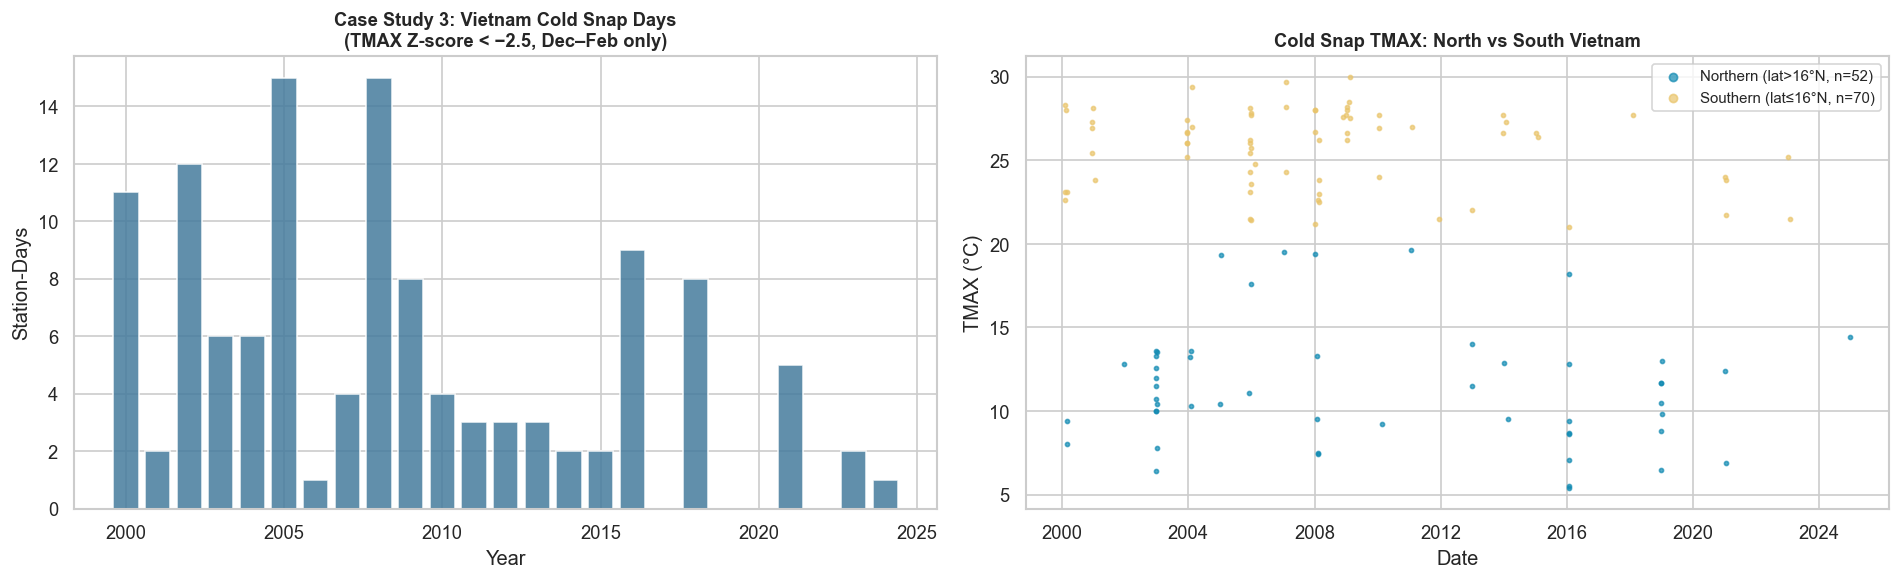

  Northern cold snaps: 52
  Southern cold snaps: 70


In [ ]:
# Case Study 3: Vietnam cold snaps — northern winter anomalies 
# Northern Vietnam (Hanoi region) experiences cold spells in Dec–Feb
cs3 = df_zscore.filter(
    (col('COUNTRY') == 'Vietnam') &
    (col('MONTH').isin([12, 1, 2])) &
    col('ANOM_COLD_SNAP')
).select('DATE', 'YEAR', 'MONTH', 'STATION_ID', 'NAME',
         'TMAX', 'TMAX_MEAN', 'TMAX_ZSCORE', 'LATITUDE') \
 .toPandas()

cs3['DATE'] = pd.to_datetime(cs3['DATE'])

# Filter to northern stations (lat > 16)
cs3_north = cs3[cs3['LATITUDE'] > 16]
cs3_south = cs3[cs3['LATITUDE'] <= 16]

cs3_yearly = cs3.groupby('YEAR').size().reset_index(name='cold_days')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(cs3_yearly['YEAR'], cs3_yearly['cold_days'],
       color='#457b9d', edgecolor='white', alpha=0.85)
ax.set_title('Case Study 3: Vietnam Cold Snap Days\n(TMAX Z-score < −2.5, Dec–Feb only)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Station-Days')

# North vs south scatter
ax = axes[1]
ax.scatter(cs3_north['DATE'], cs3_north['TMAX'], c='#118ab2', s=6, alpha=0.7,
           label=f'Northern (lat>16°N, n={len(cs3_north):,})')
ax.scatter(cs3_south['DATE'], cs3_south['TMAX'], c='#e9c46a', s=6, alpha=0.7,
           label=f'Southern (lat≤16°N, n={len(cs3_south):,})')
ax.set_title('Cold Snap TMAX: North vs South Vietnam', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('TMAX (°C)')
ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anom_07_case_study_vietnam_cold.png', bbox_inches='tight')
plt.show()
print(f"  Northern cold snaps: {len(cs3_north):,}")
print(f"  Southern cold snaps: {len(cs3_south):,}")

---
## Save Anomaly Catalogue & Summary

In [18]:
# Save combined anomaly catalogue to CSV  
if 'heatwave_catalogue' not in vars():
    heatwave_catalogue = (
        df_zscore.filter(col('ANOM_HEATWAVE'))
        .select('DATE', 'STATION_ID', 'NAME', 'COUNTRY', 'YEAR', 'MONTH',
                'TMAX', 'TMAX_MEAN', 'TMAX_STD', 'TMAX_ZSCORE')
        .withColumn('EVENT_TYPE', lit('Heatwave'))
        .toPandas()
    )
    cold_catalogue = (
        df_zscore.filter(col('ANOM_COLD_SNAP'))
        .select('DATE', 'STATION_ID', 'NAME', 'COUNTRY', 'YEAR', 'MONTH',
                'TMAX', 'TMAX_MEAN', 'TMAX_STD', 'TMAX_ZSCORE')
        .withColumn('EVENT_TYPE', lit('Cold Snap'))
        .toPandas()
    )
    n_extr_rain = df_iqr.filter(col('ANOM_EXTREME_RAIN')).count()
    n_if = iso_input['IF_ANOMALY'].sum()

# Standardise column names for export
hw_export = heatwave_catalogue[['DATE','STATION_ID','NAME','COUNTRY','YEAR','MONTH',
                                 'TMAX','TMAX_MEAN','TMAX_ZSCORE','EVENT_TYPE']].copy()
hw_export.rename(columns={'TMAX_MEAN':'BASELINE','TMAX_ZSCORE':'ZSCORE'}, inplace=True)
hw_export['SEVERITY'] = hw_export['ZSCORE'].abs().round(2)

cs_export = cold_catalogue[['DATE','STATION_ID','NAME','COUNTRY','YEAR','MONTH',
                              'TMAX','TMAX_MEAN','TMAX_ZSCORE','EVENT_TYPE']].copy()
cs_export.rename(columns={'TMAX_MEAN':'BASELINE','TMAX_ZSCORE':'ZSCORE'}, inplace=True)
cs_export['SEVERITY'] = cs_export['ZSCORE'].abs().round(2)

catalogue_full = (
    pd.concat([hw_export, cs_export], ignore_index=True)
    .sort_values('SEVERITY', ascending=False)
)

catalogue_full.to_csv(f'{OUTPUT_DIR}/anomaly_catalogue.csv', index=False)
print(f"Anomaly catalogue saved: {len(catalogue_full):,} events -> output/anomaly_catalogue.csv")

print()
print('ANOMALY DETECTION SUMMARY')
print()
print(f"Z-Score heatwaves detected:          {len(heatwave_catalogue):>8,}")
print(f"Z-Score cold snaps detected:         {len(cold_catalogue):>8,}")
print(f"IQR extreme rainfall events:         {n_extr_rain:>8,}")
print(f"Isolation Forest compound anomalies: {n_if:>8,}")
print(f"\nOutput charts saved to: {OUTPUT_DIR}/anom_*.png")

Anomaly catalogue saved: 20,869 events -> output/anomaly_catalogue.csv

ANOMALY DETECTION SUMMARY

Z-Score heatwaves detected:             2,940
Z-Score cold snaps detected:           17,929
IQR extreme rainfall events:           15,928
Isolation Forest compound anomalies:   20,228

Output charts saved to: ../output/anom_*.png
